# Stage 10a: Linear Regression

Use this as a scaffold if your project data isn’t ready. Replace the synthetic data section with your dataset when possible.

In [ ]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install scipy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install scikit-learn

In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import scipy.stats as st

sns.set()
np.random.seed(7)

## 1) Synthetic data (replace with your project data when ready)
- Finance-flavored factors and asset excess return
- Includes a quadratic effect to motivate specification checks

In [3]:
n = 200
dates = pd.bdate_range(start="2024-02-01", periods=n)
mkt_excess = np.random.normal(0, 0.011, size=n)
size = np.random.normal(0, 0.008, size=n)
value = np.random.normal(0, 0.009, size=n)
momentum = np.random.normal(0, 0.006, size=n)

beta0, beta_mkt, beta_size, beta_value, beta_mom, beta_mom2 = 0.0001, 0.9, 0.25, -0.15, 0.35, 3.5
noise_scale = 0.0035 + 0.5*np.abs(mkt_excess)
eps = np.random.normal(0, noise_scale)
asset_excess = (
    beta0 + beta_mkt*mkt_excess + beta_size*size + beta_value*value + beta_mom*momentum
    + beta_mom2*(momentum**2) + eps
)
df = pd.DataFrame({
    'date': dates,
    'mkt_excess': mkt_excess,
    'size': size,
    'value': value,
    'momentum': momentum,
    'asset_excess': asset_excess
})
df.head()

,date,mkt_excess,size,value,momentum,asset_excess
0,2024-02-01,0.018596,-0.013467,-0.000540,0.000141,0.014832
1,2024-02-02,-0.005125,0.008120,0.007089,-0.006840,-0.008599
2,2024-02-05,0.000361,-0.011532,-0.012885,-0.011216,-0.009577
3,2024-02-06,0.004483,-0.010749,0.003905,-0.010685,0.000033
4,2024-02-07,-0.008678,-0.002893,0.001250,0.002779,-0.005750


## 2) Baseline model fit
Follow the steps; replace `df` with your project DataFrame when ready.

In [4]:
X = df[['mkt_excess','size','value','momentum']]
y = df['asset_excess']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Baseline   R²={r2:.4f}  RMSE={rmse:.6f}')

Baseline   R²=0.3677  RMSE=0.008470


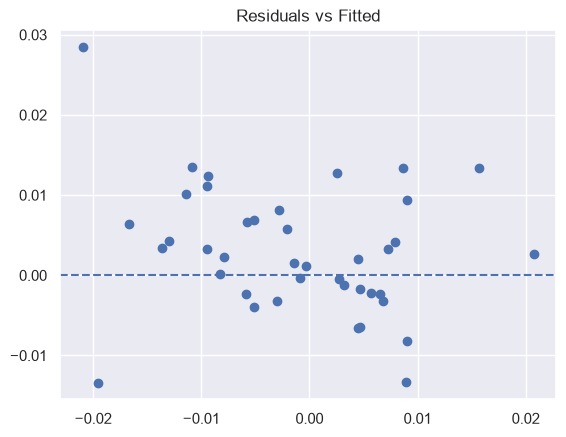

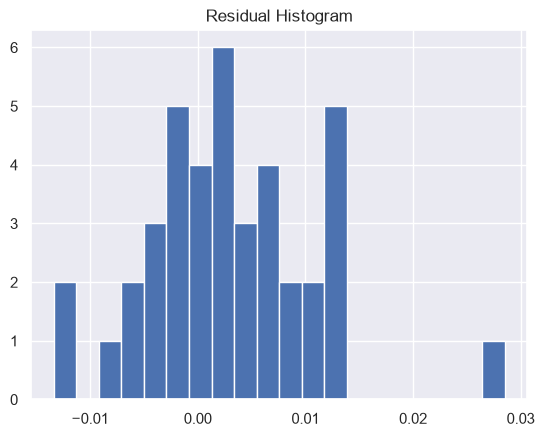

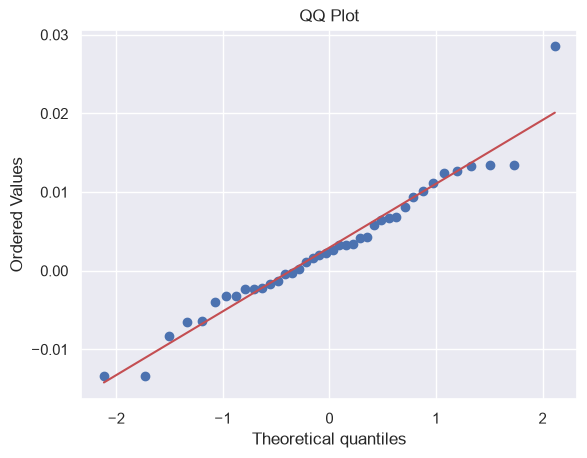

In [5]:
resid = y_test - y_pred
fitted = y_pred
plt.figure(); plt.scatter(fitted, resid); plt.axhline(0, ls='--'); plt.title('Residuals vs Fitted'); plt.show()
plt.figure(); plt.hist(resid, bins=20); plt.title('Residual Histogram'); plt.show()
plt.figure(); st.probplot(resid, dist='norm', plot=plt); plt.title('QQ Plot'); plt.show()

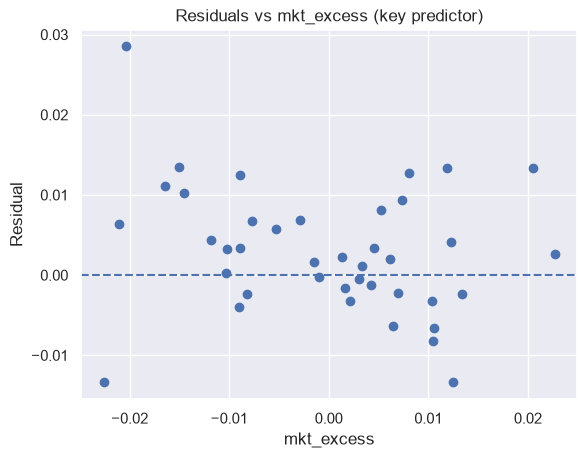

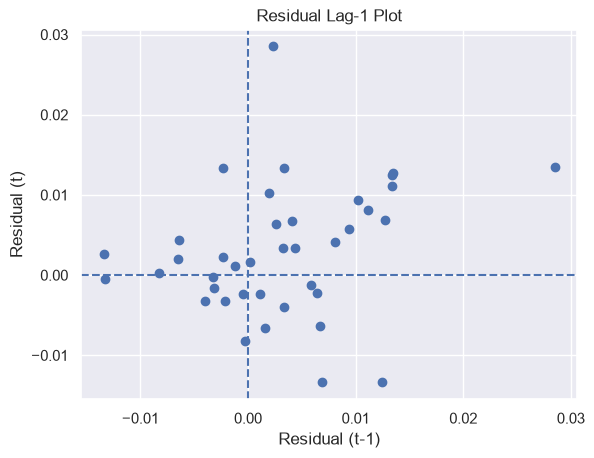

Lag-1 autocorrelation of residuals = 0.2600


In [6]:
# Optional diagnostics: residuals vs a key predictor, and residual lag-1 (autocorrelation check)

# Residuals vs a key predictor (mkt_excess)
plt.figure()
plt.scatter(X_test['mkt_excess'], resid)
plt.axhline(0, ls='--')
plt.xlabel('mkt_excess'); plt.ylabel('Residual')
plt.title('Residuals vs mkt_excess (key predictor)')
plt.show()

# Residual lag-1 plot (checks independence / autocorrelation)
resid_arr = resid.values
plt.figure()
plt.scatter(resid_arr[:-1], resid_arr[1:])
plt.axhline(0, ls='--'); plt.axvline(0, ls='--')
plt.xlabel('Residual (t-1)'); plt.ylabel('Residual (t)')
plt.title('Residual Lag-1 Plot')
plt.show()

lag1_corr = np.corrcoef(resid_arr[:-1], resid_arr[1:])[0,1]
print(f'Lag-1 autocorrelation of residuals = {lag1_corr:.4f}')

## 3) Optional: Add a transformed feature
Add a polynomial or interaction if diagnostics suggest mis-specification.

In [7]:
df['momentum_sq'] = df['momentum']**2
X2 = df[['mkt_excess','size','value','momentum','momentum_sq']]
X2_train, X2_test = X2.iloc[:len(X_train)], X2.iloc[len(X_train):]
lr2 = LinearRegression().fit(X2_train, y_train)
y_pred2 = lr2.predict(X2_test)
r2_2 = r2_score(y_test, y_pred2)
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred2))
print(f'With x^2   R²={r2_2:.4f}  RMSE={rmse_2:.6f}')

With x^2   R²=0.3681  RMSE=0.008467


## 4) Interpretation (write your conclusions below)
- Linearity: The Residuals-vs-Fitted plot shows points scattered fairly evenly around zero, without a clear systematic curve or U-shape (aside from one isolated outlier near +0.028). This suggests the baseline linear specification is reasonably adequate — there's no strong visual evidence of an unmodeled nonlinear pattern in the residuals.
- Homoscedasticity: Looking at the same Residuals vs Fitted plot, the vertical spread of points doesn't show an obvious widening or narrowing pattern as fitted values increase — the scatter looks roughly consistent across the range, aside from the one outlier. Based on visual inspection alone, there's no strong evidence of heteroscedasticity, though the spread isn't perfectly uniform either.
- Normality: The histogram is roughly bell-shaped and centered near zero, though slightly right-skewed with one large positive outlier. The QQ plot shows most points falling close to the reference line, with just the two tail points deviating slightly. Overall, the residuals look reasonably close to normal.
- Independence: The optional residual lag-1 plot shows a mild positive relationship between consecutive residuals (lag-1 correlation ≈ 0.26) — points lean toward the upper-right and lower-left quadrants rather than scattering randomly. This suggests some mild positive autocorrelation, so independence is only partially supported; residuals from one period may carry some information about the next.
- Which model do you trust and why?:  The two models perform almost identically (R²: 0.3677 vs. 0.3681; RMSE barely changes). Adding `momentum_sq` gives essentially no improvement in predictive performance on the test set. I trust the **baseline model** — it's simpler, and the added complexity of the quadratic term isn't justified by any meaningful gain in fit.
- Next step you’d try: 